In [12]:
!pip install requests

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [13]:
import pandas as pd
import os

import requests
import json

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
marathons = pd.read_csv('Results.csv')

In [15]:
print(marathons.head())

                Race  Year                Name Gender  Age  Finish Age Bracket
0  Columbus Marathon  2015      Becky Williams      F   29   13645    Under 35
1  Columbus Marathon  2015     Jessica Sheahan      F   27   13648    Under 35
2  Columbus Marathon  2015        Kelsey Stief      F   27   13650    Under 35
3  Columbus Marathon  2015        Mehgan Cline      F   26   13650    Under 35
4  Columbus Marathon  2015  Stefanie Driesenga      F   28   13652    Under 35


In [16]:
# View the shape of the dataframe to get number of rows and columns
print(marathons.shape) 

# View the different columns in the marathons dataframe to see what info I am working with
print(marathons.columns)

(2053366, 7)
Index(['Race', 'Year', 'Name', 'Gender', 'Age', 'Finish', 'Age Bracket'], dtype='object')


In [17]:
# Change column 'Finish' to be 'FinishTime'
marathons = marathons.rename(columns = {'Finish' : 'FinishTime'})
print(marathons)

                          Race  Year                Name Gender  Age  \
0            Columbus Marathon  2015      Becky Williams      F   29   
1            Columbus Marathon  2015     Jessica Sheahan      F   27   
2            Columbus Marathon  2015        Kelsey Stief      F   27   
3            Columbus Marathon  2015        Mehgan Cline      F   26   
4            Columbus Marathon  2015  Stefanie Driesenga      F   28   
...                        ...   ...                 ...    ...  ...   
2053361  Marine Corps Marathon  2019         Daryl Young      M   39   
2053362  Marine Corps Marathon  2019        Ella Biggins      F   24   
2053363  Marine Corps Marathon  2019          Kevin Klym      M   44   
2053364  Marine Corps Marathon  2019     Casey A Shapiro      F   34   
2053365  Marine Corps Marathon  2019         Zhaowei Liu      M   64   

         FinishTime Age Bracket  
0             13645    Under 35  
1             13648    Under 35  
2             13650    Under 35  

In [18]:
# Find all unique years of races
marathons['Year'].unique()

array([2015, 2010, 2019, 2012, 2011, 2018, 2013, 2014, 2017, 2016])

In [19]:
# Converting the time column to a readable time instead of seconds
marathons["FinishTime"] = pd.to_timedelta(marathons["FinishTime"], unit="s")

# Figure out how to get rid of days in Finish Time

In [20]:
marathons.head()

,Race,Year,Name,Gender,Age,FinishTime,Age Bracket
0,Columbus Marathon,2015,Becky Williams,F,29,0 days 03:47:25,Under 35
1,Columbus Marathon,2015,Jessica Sheahan,F,27,0 days 03:47:28,Under 35
2,Columbus Marathon,2015,Kelsey Stief,F,27,0 days 03:47:30,Under 35
3,Columbus Marathon,2015,Mehgan Cline,F,26,0 days 03:47:30,Under 35
4,Columbus Marathon,2015,Stefanie Driesenga,F,28,0 days 03:47:32,Under 35


In [21]:
# Race participation

# Find all unique races
marathons['Race'].unique()

# Decided to use information for the Philadelphia Marathon, Chicago Marathon, and NYC Marathon 

# Narrowing the results to be the years we want (2015-2019)
marathons2015_2019 = marathons[(marathons['Year'] >= 2015) & (marathons['Year'] <= 2019)]

# Philadelphia marathon
print("===Philadelphia Marathon Participation===")
years = marathons2015_2019.groupby('Race')
Philly_thru_years = years.get_group('Philadelphia Marathon')
# print(Philly_thru_years)
Philly_years = Philly_thru_years.groupby('Year').size()

# Creating dataframe consisting of Philly finishers
Philly_finishers = Philly_years.reset_index(name = "Finishers")
print("===Philadelphia Marathon Finishers===")
print(Philly_finishers)

# Print the year with max participation and minimum participation 
max_Philly = Philly_years.max()
max_Philly_year = Philly_years.idxmax()

min_Philly = Philly_years.min()
min_Philly_year = Philly_years.idxmin()

print(f"Maximum participation = {max_Philly_year} : {max_Philly}")
print(f"Minimum participation = {min_Philly_year} : {min_Philly}")

# Chicago marathon
print("===Chicago Marathon Participation===")
years = marathons2015_2019.groupby('Race')
Chicago_thru_years = years.get_group('Chicago Marathon')
# print(Chicago_thru_years)
Chicago_years = Chicago_thru_years.groupby('Year').size()

# Creating a dataframe consisting of Chicago Marathon finishers
Chicago_finishers = Chicago_years.reset_index(name = "Finishers")
print("===Chicago Finishers===")
print(Chicago_finishers)

# Print the year with max participation and minimum participation 
max_Chicago = Chicago_years.max()
max_Chicago_year = Chicago_years.idxmax()

min_Chicago = Chicago_years.min()
min_Chicago_year = Chicago_years.idxmin()

print(f"Maximum participation = {max_Chicago_year} : {max_Chicago}")
print(f"Minimum participation = {min_Chicago_year} : {min_Chicago}")

# NYC marathon
print("===NYC Marathon Participation===")
years = marathons2015_2019.groupby('Race')
NYC_thru_years = years.get_group('NYC Marathon')
# print(NYC_thru_years)
NYC_years = NYC_thru_years.groupby('Year').size()

# Creating dataframe consisting of NYC Marathon finishers
NYC_finishers = NYC_years.reset_index(name = "Finishers")
print("===NYC Marathon Finishers===")
print(NYC_finishers)

# Print the year with max participation and minimum participation 
max_NYC = NYC_years.max()
max_NYC_year = NYC_years.idxmax()

min_NYC = NYC_years.min()
min_NYC_year = NYC_years.idxmin()

print(f"Maximum participation = {max_NYC_year} : {max_NYC}")
print(f"Minimum participation = {min_NYC_year} : {min_NYC}")


===Philadelphia Marathon Participation===
===Philadelphia Marathon Finishers===
   Year  Finishers
0  2015       9153
1  2016       8982
2  2017       7761
3  2018       9509
4  2019      10041
Maximum participation = 2019 : 10041
Minimum participation = 2017 : 7761
===Chicago Marathon Participation===
===Chicago Finishers===
   Year  Finishers
0  2015      37442
1  2016      40557
2  2017      44348
3  2018      44551
4  2019      45867
Maximum participation = 2019 : 45867
Minimum participation = 2015 : 37442
===NYC Marathon Participation===
===NYC Marathon Finishers===
   Year  Finishers
0  2015      49461
1  2016      51274
2  2017      50641
3  2018      52706
4  2019      53520
Maximum participation = 2019 : 53520
Minimum participation = 2015 : 49461


In [22]:
# Findings

print('''Findings
For the most part, participation increased each year. This is likely due to more people knowing 
about the marathon through increased advertising/word of mouth. The one exception is the Philadelphia Marathon
where 2017 had the minimum participation, with the first year we looked at (2015) having the 3rd highest
participation. We will look in to see whether weather had anything to do with this next.''')


Findings
For the most part, participation increased each year. This is likely due to more people knowing 
about the marathon through increased advertising/word of mouth. The one exception is the Philadelphia Marathon
where 2017 had the minimum participation, with the first year we looked at (2015) having the 3rd highest
participation. We will look in to see whether weather had anything to do with this next.


In [23]:
# Adding race column to each of the finishers data frames

Philly_finishers['Race'] = "Philadelphia Marathon"
Chicago_finishers['Race'] = "Chicago Marathon"
NYC_finishers['Race'] = "NYC Marathon"

# Combining the three finishers dataframes into one dataframe
finishers = pd.concat([
    Philly_finishers,
    Chicago_finishers, 
    NYC_finishers],
    ignore_index = True)

print(finishers)

    Year  Finishers                   Race
0   2015       9153  Philadelphia Marathon
1   2016       8982  Philadelphia Marathon
2   2017       7761  Philadelphia Marathon
3   2018       9509  Philadelphia Marathon
4   2019      10041  Philadelphia Marathon
5   2015      37442       Chicago Marathon
6   2016      40557       Chicago Marathon
7   2017      44348       Chicago Marathon
8   2018      44551       Chicago Marathon
9   2019      45867       Chicago Marathon
10  2015      49461           NYC Marathon
11  2016      51274           NYC Marathon
12  2017      50641           NYC Marathon
13  2018      52706           NYC Marathon
14  2019      53520           NYC Marathon


In [24]:
# Find the date of each marathon during span of 2015 - 2019

# Entering API weather key
API_KEY = 'KPXYUH9NL88LWFGLKXYH8P3Y8'

# Creating weather dictionary to store data in 
weather_data = []

# Philly race dates
philly_race_dates = {
    2015: '2015-11-22',
    2016: '2016-11-20',
    2017: '2017-11-19',
    2018: '2018-11-18',
    2019: '2019-11-24'
}

# NYC race dates
NYC_race_dates = {
    2015: '2015-11-01',
    2016: '2016-11-06',
    2017: '2017-11-05',
    2018: '2018-11-04',
    2019: '2019-11-03'
}

# Chicago race dates
chicago_race_dates = {
    2015: '2015-10-11',
    2016: '2016-10-09',
    2017: '2017-10-08',
    2018: '2018-10-07',
    2019: '2019-10-13'
}

# == Philly weather ==

location = 'Philadelphia,PA'

for year, date in philly_race_dates.items():

    url = (
        f"https://weather.visualcrossing.com/"
        f"VisualCrossingWebServices/rest/services/timeline/"
        f"{location}/{date}"
        f"?unitGroup=us"
        f"&include=days"
        f"&key={API_KEY}"
        f"&contentType=json"
    )

    response = requests.get(url)
    
    # If url works, get weather information for each of the years
    if response.status_code == 200:
        weather = response.json()

        day = weather['days'][0]

        # Weather information needed = max temp, min temp, humidity, windspeed, and precipitation amounts
        weather_data.append({
            "Race": "Philadelphia Marathon",
            "Year": year,
            "TempMax": day['tempmax'],
            "TempMin": day['tempmin'],
            "Humidity": day['humidity'],
            "WindSpeed": day['windspeed'],
            "Precipitation": day['precip']
            })
        
    # Tells to print an error code with year if unsuccessful
    else:
        print(f"Error for {year}: {response.status_code}")

# Creating a weather data dataframe to store the data in
weather = pd.DataFrame(weather_data)


# NYC weather

location = 'New York City,NY'

for year, date in NYC_race_dates.items():
        
    url = (
        f"https://weather.visualcrossing.com/"
        f"VisualCrossingWebServices/rest/services/timeline/"
        f"{location}/{date}"
        f"?unitGroup=us"
        f"&include=days"
        f"&key={API_KEY}"
        f"&contentType=json"
    )

    response = requests.get(url)

    # If url works, get requested weather data for that date
    if response.status_code == 200:
        weather = response.json()

        day = weather['days'][0]

        weather_data.append({
            "Race": "NYC Marathon",
            "Year": year,
            "TempMax": day['tempmax'],
            "TempMin": day['tempmin'],
            "Humidity": day['humidity'],
            "WindSpeed": day['windspeed'],
            "Precipitation": day['precip']
        })

    # Tells to print year and error if unsuccessful
    else: 
        print(f"Error for {year} : {response.status_code}")

# == Chicago Weather == 


location = 'Chicago, IL'

for year, date in chicago_race_dates.items():
        
    url = (
        f"https://weather.visualcrossing.com/"
        f"VisualCrossingWebServices/rest/services/timeline/"
        f"{location}/{date}"
        f"?unitGroup=us"
        f"&include=days"
        f"&key={API_KEY}"
        f"&contentType=json"
    )

    response = requests.get(url)

    # If url works, get requested weather data for that date
    if response.status_code == 200:
        weather = response.json()

        day = weather['days'][0]

        weather_data.append({
            "Race": "Chicago Marathon",
            "Year": year,
            "TempMax": day['tempmax'],
            "TempMin": day['tempmin'],
            "Humidity": day['humidity'],
            "WindSpeed": day['windspeed'],
            "Precipitation": day['precip']
        })

    # Tells to print year and error if unsuccessful
    else: 
        print(f"Error for {year} : {response.status_code}")

# Converting weather_data to data frame
weather_df = pd.DataFrame(weather_data)
                                
            
    
# Chicago weather

In [25]:
# Print the weather dataframe
print(weather_df)

                     Race  Year  TempMax  TempMin  Humidity  WindSpeed  \
0   Philadelphia Marathon  2015     51.9     41.4      53.2       14.5   
1   Philadelphia Marathon  2016     43.2     38.1      51.6       28.4   
2   Philadelphia Marathon  2017     60.7     40.6      57.6       28.5   
3   Philadelphia Marathon  2018     47.6     32.8      73.7        6.6   
4   Philadelphia Marathon  2019     46.4     38.7      75.7       19.2   
5            NYC Marathon  2015     64.5     53.1      64.0        9.9   
6            NYC Marathon  2016     57.7     46.1      50.8       15.7   
7            NYC Marathon  2017     61.3     51.8      86.5        9.2   
8            NYC Marathon  2018     55.5     43.3      55.3       11.7   
9            NYC Marathon  2019     52.2     42.5      48.9        9.9   
10       Chicago Marathon  2015     78.8     52.6      53.0       18.2   
11       Chicago Marathon  2016     62.6     49.5      66.6       13.0   
12       Chicago Marathon  2017     79

In [26]:
# Merging marathons into weather_data to add a participation column allowing for easier comparisons and analysis

weather_df = weather_df.merge(
    finishers[['Race','Year','Finishers']],
    on = ['Race','Year'],
    how = 'left')


print(weather_df)

               

                     Race  Year  TempMax  TempMin  Humidity  WindSpeed  \
0   Philadelphia Marathon  2015     51.9     41.4      53.2       14.5   
1   Philadelphia Marathon  2016     43.2     38.1      51.6       28.4   
2   Philadelphia Marathon  2017     60.7     40.6      57.6       28.5   
3   Philadelphia Marathon  2018     47.6     32.8      73.7        6.6   
4   Philadelphia Marathon  2019     46.4     38.7      75.7       19.2   
5            NYC Marathon  2015     64.5     53.1      64.0        9.9   
6            NYC Marathon  2016     57.7     46.1      50.8       15.7   
7            NYC Marathon  2017     61.3     51.8      86.5        9.2   
8            NYC Marathon  2018     55.5     43.3      55.3       11.7   
9            NYC Marathon  2019     52.2     42.5      48.9        9.9   
10       Chicago Marathon  2015     78.8     52.6      53.0       18.2   
11       Chicago Marathon  2016     62.6     49.5      66.6       13.0   
12       Chicago Marathon  2017     79

In [27]:
# Weather and participation analysis

print('''===Philadelphia Marathon Weather - Participation Analysis===
It appears that when it rains a lot, the participation drops by 1000 - 2000. This is not the case in the Philadelphia 2019. This race had .886 inches of 
rain and had no effect on the participation. Participation actually increased during this race. It is possible that it rained later in the day than the 
marathon. In 2017, however, when it rained .29 in and the temperature was considerably higher (60.7 degrees fahrenheit), participation was noticeably lower,
being only 7761. Also, in the two lower participation races for the Philadelphia Marathon (2016 and 2017), there was a very high wind speed which could've 
attributed to lower participation.''')

print('''===NYC Marathon Weather - Participation Analysis===
The NYC marathon has had decent weather in regards to participation amounts between 2015-2019. In 2017 when it rained .048 inches, participation dropped about
1000. This could be due to other factors however, as .048 inches isn't much rain. The humidity in 2017 was also at 86.5% which is considerably higher than the
other years, perhaps attributing to the lower participation. ''')

print('''===Chicago Marathon Weather - Participation Analysis===
The Chicago marathon also had decent weather in regards to participation. The only year it rained was in 2018 when it rained .602 inches. There wasn't any dip
in participation for this race, however. It could have been in a different part of the day than when the marathon was taking place. The Chicago marathon is
the only marathon (of the ones I am looking at) that doesn't seem to be affected by the weather. Despite a high humidity rate and the rain in 2018, 
participation remained strong.''')

===Philadelphia Marathon Weather - Participation Analysis===
It appears that when it rains a lot, the participation drops by 1000 - 2000. This is not the case in the Philadelphia 2019. This race had .886 inches of 
rain and had no effect on the participation. Participation actually increased during this race. It is possible that it rained later in the day than the 
marathon. In 2017, however, when it rained .29 in and the temperature was considerably higher (60.7 degrees fahrenheit), participation was noticeably lower,
being only 7761. Also, in the two lower participation races for the Philadelphia Marathon (2016 and 2017), there was a very high wind speed which could've 
attributed to lower participation.
===NYC Marathon Weather - Participation Analysis===
The NYC marathon has had decent weather in regards to participation amounts between 2015-2019. In 2017 when it rained .048 inches, participation dropped about
1000. This could be due to other factors however, as .048 inches isn't mu

--- Temperature Max vs Participation ---
- Philadelphia Marathon -
                    Race  Year  TempMax  TempMin  Humidity  WindSpeed  \
0  Philadelphia Marathon  2015     51.9     41.4      53.2       14.5   
1  Philadelphia Marathon  2016     43.2     38.1      51.6       28.4   
2  Philadelphia Marathon  2017     60.7     40.6      57.6       28.5   
3  Philadelphia Marathon  2018     47.6     32.8      73.7        6.6   
4  Philadelphia Marathon  2019     46.4     38.7      75.7       19.2   

   Precipitation  Finishers  
0          0.000       9153  
1          0.004       8982  
2          0.290       7761  
3          0.000       9509  
4          0.886      10041  
- Chicago Marathon -
                Race  Year  TempMax  TempMin  Humidity  WindSpeed  \
10  Chicago Marathon  2015     78.8     52.6      53.0       18.2   
11  Chicago Marathon  2016     62.6     49.5      66.6       13.0   
12  Chicago Marathon  2017     79.5     55.2      64.6       19.0   
13  Chicago Marat

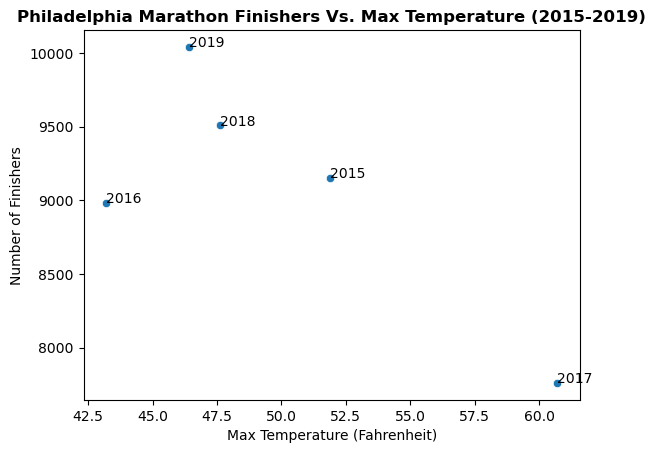

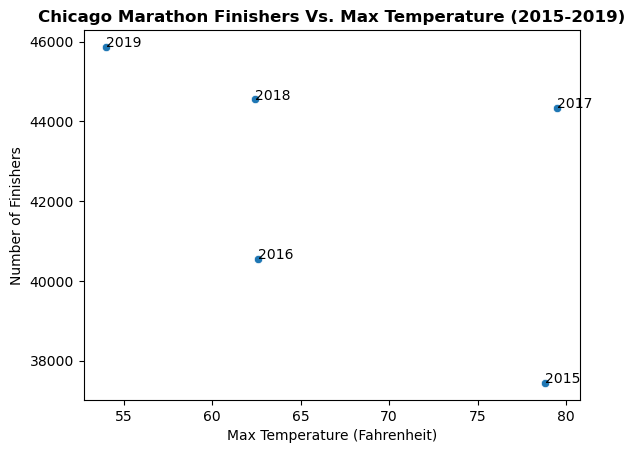

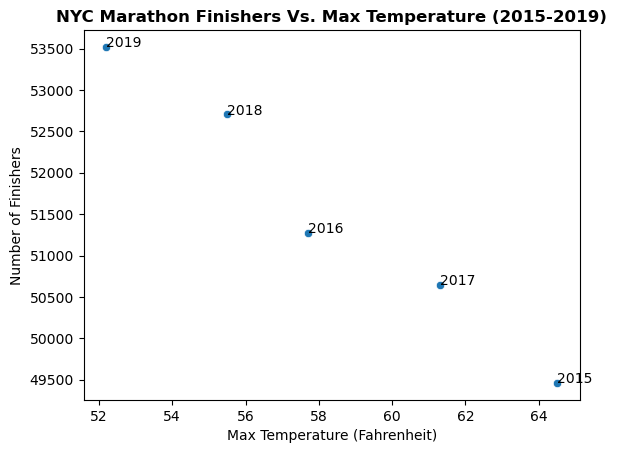

In [28]:
# Graph of temp max, temp min, and finishers throughout years


print("--- Temperature Max vs Participation ---")

# Creating the Philly scatterplot for temp max vs participation
print("- Philadelphia Marathon -")
philly_weatherDF = weather_df[weather_df['Race'] == 'Philadelphia Marathon']
print(philly_weatherDF)

philly_finisher_SP = sns.scatterplot(data = philly_weatherDF, x = "TempMax", y = "Finishers")

# Adding x, y, and title labels to graph
plt.xlabel("Max Temperature (Fahrenheit)")
plt.ylabel("Number of Finishers")
plt.title("Philadelphia Marathon Finishers Vs. Max Temperature (2015-2019)", fontsize = 12, fontweight = "bold")

# Add year labels to each point
for i, row in philly_weatherDF.iterrows():
    plt.text(
        row['TempMax'],
        row['Finishers'],
        str(row['Year'])
    )

# Creating the Chicago scatterplot for temp max vs participation
print("- Chicago Marathon -")
chicago_weatherDF = weather_df[weather_df['Race'] == "Chicago Marathon"]
print(chicago_weatherDF)

# Creating a new graph for Chicago so it doesn't combine with Philly graph
plt.figure()

chicago_finisher_SP = sns.scatterplot(data = chicago_weatherDF, x = "TempMax", y = "Finishers")

# Adding x, y, and title labels to graph
plt.xlabel("Max Temperature (Fahrenheit)")
plt.ylabel("Number of Finishers")
plt.title("Chicago Marathon Finishers Vs. Max Temperature (2015-2019)", fontsize = 12, fontweight = "bold")
print(chicago_finisher_SP)

# Add year labels to each point
for i, row in chicago_weatherDF.iterrows():
    plt.text(
        row['TempMax'],
        row['Finishers'],
        str(row['Year'])
    )

# Creating scatterplot for NYC Marathon Temp Max Vs. Participation
print("- NYC Marathon-")
NYC_weatherDF = weather_df[weather_df['Race'] == "NYC Marathon"]
print(NYC_weatherDF)

# Creating new graph so it doesn't overwrite previous
plt.figure()

sns.scatterplot(data = NYC_weatherDF, x = "TempMax", y = "Finishers")

# Adding x, y, and title labels to the graph
plt.xlabel("Max Temperature (Fahrenheit)")
plt.ylabel("Number of Finishers")
plt.title("NYC Marathon Finishers Vs. Max Temperature (2015-2019)", fontsize = 12, fontweight = "bold")

# Add year labels to each point
for i, row in NYC_weatherDF.iterrows():
    plt.text(
        row['TempMax'],
        row['Finishers'],
        str(row['Year'])
    )
        

In [29]:
print('''Max Temperature vs. Finishers Findings
Most of the races appear to be gaining popularity as the years go on, which is what one would expect to find. In the 
Philly Marathon, however, temperature may have had an impact on the amount of finishers in 2017. The temperature was 
60.7 and the amount of finishers was much lower than previous years. There also seems to be a strong negative 
correlation between NYC temperature and finishers. This suggests that runners on hotter days are less likely to 
finish the race than on cooler days.''')


Max Temperature vs. Finishers Findings
Most of the races appear to be gaining popularity as the years go on, which is what one would expect to find. In the 
Philly Marathon, however, temperature may have had an impact on the amount of finishers in 2017. The temperature was 
60.7 and the amount of finishers was much lower than previous years. There also seems to be a strong negative 
correlation between NYC temperature and finishers. This suggests that runners on hotter days are less likely to 
finish the race than on cooler days.


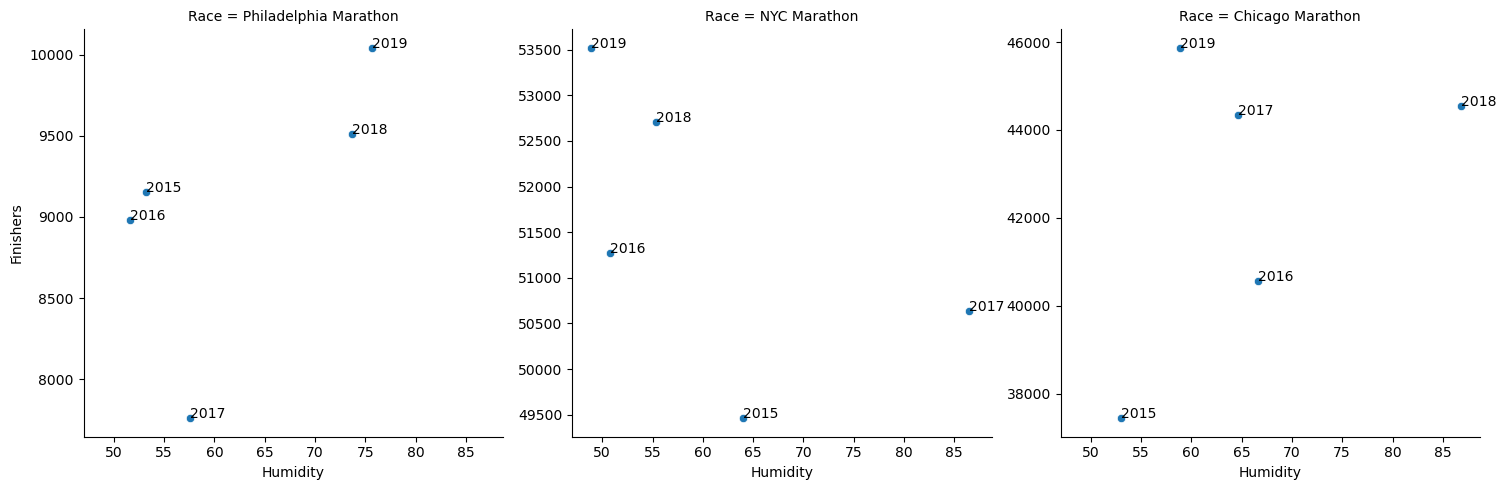

In [39]:
# Graph of humidity and finishers throughout years

''' I used relplot to show the graphs side by side and used sharey = false to allow the y axis to show the difference in 
the amount of finishers. I thought this was the better way to do it as NYC and Chicago have a substantial difference
in finishers each year (about 40,000 more) '''

graphs = sns.relplot(
    data = weather_df,
    x = 'Humidity',
    y = 'Finishers',
    col = 'Race', 
    kind = 'scatter',
    facet_kws = {'sharey' : False}
)

# Adding labels to graph
for graph, race_name in zip(graphs.axes.flat, weather_df['Race'].unique()):
    race_data = weather_df[weather_df['Race'] == race_name]

    for _, row in race_data.iterrows():
        graph.text(
            row['Humidity'],
            row['Finishers'],
            str(row['Year'])
        )

In [41]:
print('''Marathon Humidity vs. Participation
None of these graphs show a strong correlation between humidity and finishers. Most of the races show increase 
in participation throughout the years. The only exception is the NYC Marathon in 2017 where a humidity of 86.5% led to 
lower participation''')

Marathon Humidity vs. Participation
None of these graphs show a strong correlation between humidity and finishers. Most of the races show increase 
in participation throughout the years. The only exception is the NYC Marathon in 2017 where a humidity of 86.5% led to 
lower participation


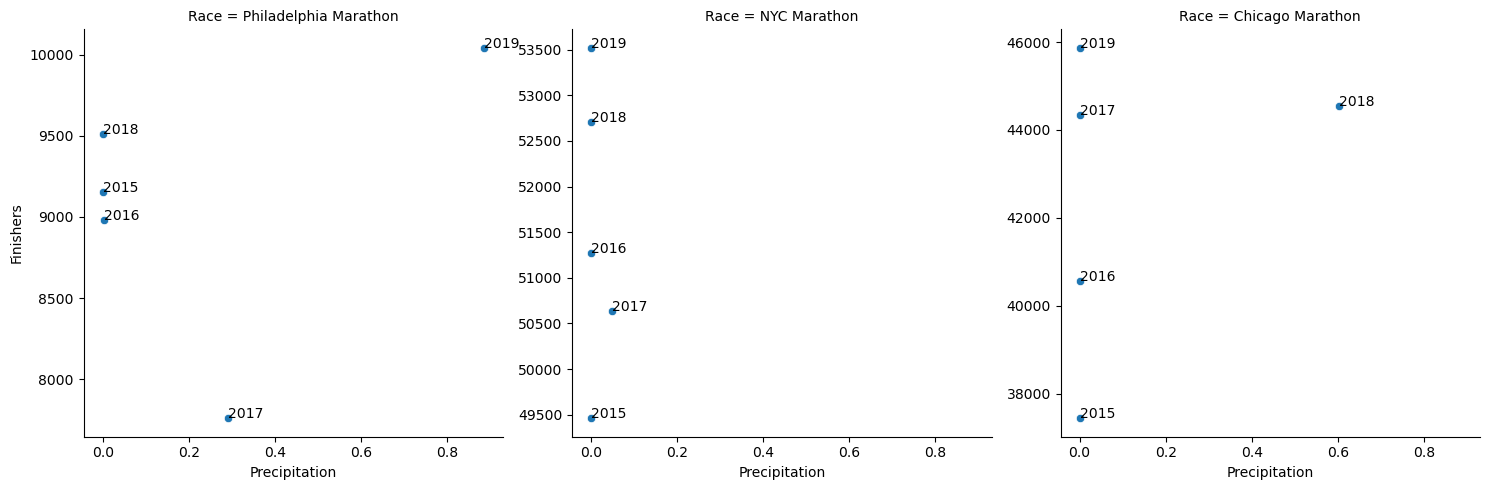

In [42]:
# Graph of precipitation and finishers throughout years

graphs = sns.relplot(
    data = weather_df, 
    x = 'Precipitation',
    y = 'Finishers',
    col = 'Race',
    kind = 'scatter',
    facet_kws = {'sharey' : False}
)

# Adding labels to graph
for graph, race_name in zip(graphs.axes.flat, weather_df['Race'].unique()):
    race_data = weather_df[weather_df['Race'] == race_name]

    for _, row in race_data.iterrows():
        graph.text(
            row['Precipitation'],
            row['Finishers'],
            str(row['Year'])
        )

In [43]:
print('''Marathon Precipitation vs Finishers Findings
Most of these races fell on days with little to no precipitation with the exception of Philadelphia 2017 and Chicago 2018.
Philadelphia 2017 led to significantly less participation, although the temperature was also high on that day being 60.7 
degrees Fahrenheit. In the Chicago 2018 Marathon, the rain doesn't seem to have impacted the increasing participation 
over the years. ''')

Marathon Precipitation vs Finishers Findings
Most of these races fell on days with little to no precipitation with the exception of Philadelphia 2017 and Chicago 2018.
Philadelphia 2017 led to significantly less participation, although the temperature was also high on that day being 60.7 
degrees Fahrenheit. In the Chicago 2018 Marathon, the rain doesn't seem to have impacted the increasing participation 
over the years. 


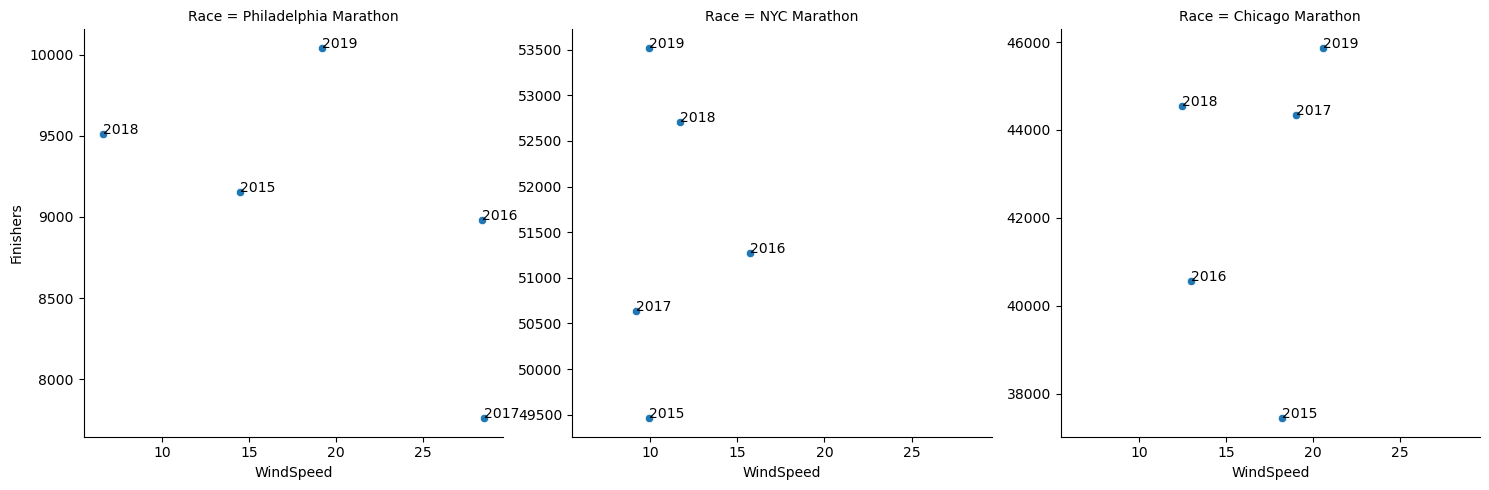

In [44]:
# Graph of wind speed and finishers throughout years

graphs = sns.relplot(
    data = weather_df,
    x = 'WindSpeed',
    y = 'Finishers',
    col = 'Race',
    kind = 'scatter', 
    facet_kws = {'sharey' : False}
)

# Adding labels to graph
for graph, race_name in zip(graphs.axes.flat, weather_df['Race'].unique()):
    race_data = weather_df[weather_df['Race'] == race_name]

    for _, row in race_data.iterrows():
        graph.text(
            row['WindSpeed'],
            row['Finishers'],
            str(row['Year'])
        )

In [46]:
print('''Wind Speed doesn't seem to affect participation much throughout the years. NYC Marathon has a pretty normal
wind speed throughout the years. Chicago also seems unaffected by wind speed. The only exception would be the 
Philadelphia Marathon where in 2017 there was significantly lower participation when wind speeds hit 28.5
''')

print('''Overall weather doesn't seem to have a very strong correlation on the amount of finishers. This is probably 
because runners have to pay in advance and have been training for so long to do the Marathon that it doesn't make sense
not to. The one exception is the Philadelphia Marathon in 2017. This Marathon was on a day where it had high temperatures, 
high humidity, and high wind speeds. This race saw a dramatically lower amount of finishers and this could be attributed 
to the weather conditions seen on this day.''')

Wind Speed doesn't seem to affect participation much throughout the years. NYC Marathon has a pretty normal
wind speed throughout the years. Chicago also seems unaffected by wind speed. The only exception would be the 
Philadelphia Marathon where in 2017 there was significantly lower participation when wind speeds hit 28.5

Overall weather doesn't seem to have a very strong correlation on the amount of finishers. This is probably 
because runners have to pay in advance and have been training for so long to do the Marathon that it doesn't make sense
not to. The one exception is the Philadelphia Marathon in 2017. This Marathon was on a day where it had high temperatures, 
high humidity, and high wind speeds. This race saw a dramatically lower amount of finishers and this could be attributed 
to the weather conditions seen on this day.


In [34]:
# NYC Marathon Analysis

In [35]:
# 20

In [36]:
# correlation analysis,